In [2]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names"
)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [3]:
df = pd.read_csv(r"C:\Users\cecil\Cript_Anomalies\BTCUSDT_20180101_20260112.csv", delimiter=";", skiprows=0)
display(df)

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,n_trades,taker_buy_base,...,ignore,symbol,interval,log_return,volatility_20,range_hl,trades_per_volume,buy_ratio,z_return,anomaly_simple
0,2018-01-01 00:00:00+00:00,13715.65,13715.65,13400.01,13556.15,123.616013,2018-01-01 00:14:59.999000+00:00,1.675545e+06,1572,63.227133,...,0,BTCUSDT,15m,NaN,NaN,0.023013,12.716799,0.511480,NaN,False
1,2018-01-01 00:15:00+00:00,13533.75,13550.87,13402.00,13521.12,98.136430,2018-01-01 00:29:59.999000+00:00,1.321757e+06,1461,47.686389,...,0,BTCUSDT,15m,-0.002587,NaN,0.011000,14.887438,0.485919,-0.691986,False
2,2018-01-01 00:30:00+00:00,13500.00,13545.37,13450.00,13470.41,79.904037,2018-01-01 00:44:59.999000+00:00,1.078825e+06,1000,43.710406,...,0,BTCUSDT,15m,-0.003757,NaN,0.007064,12.515012,0.547036,-1.004095,False
3,2018-01-01 00:45:00+00:00,13494.65,13690.87,13450.00,13529.01,141.699719,2018-01-01 00:59:59.999000+00:00,1.917783e+06,1195,73.897993,...,0,BTCUSDT,15m,0.004341,NaN,0.017849,8.433327,0.521511,1.156086,False
4,2018-01-01 01:00:00+00:00,13528.99,13571.74,13402.28,13445.63,72.537533,2018-01-01 01:14:59.999000+00:00,9.778198e+05,898,34.257652,...,0,BTCUSDT,15m,-0.006182,NaN,0.012526,12.379798,0.472275,-1.650855,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281126,2026-01-12 22:30:00+00:00,91269.52,91402.81,91203.69,91339.90,86.681550,2026-01-12 22:44:59.999000+00:00,7.912440e+06,28813,50.482400,...,0,BTCUSDT,15m,0.000771,0.001837,0.002182,332.400609,0.582389,0.203804,False
281127,2026-01-12 22:45:00+00:00,91339.89,91339.90,91214.00,91244.99,60.451790,2026-01-12 22:59:59.999000+00:00,5.517664e+06,19198,18.105290,...,0,BTCUSDT,15m,-0.001040,0.001788,0.001378,317.575377,0.299500,-0.279123,False
281128,2026-01-12 23:00:00+00:00,91244.99,91280.99,91059.88,91160.07,180.361250,2026-01-12 23:14:59.999000+00:00,1.643558e+07,26239,91.014310,...,0,BTCUSDT,15m,-0.000931,0.001721,0.002423,145.480251,0.504622,-0.250178,False
281129,2026-01-12 23:15:00+00:00,91160.07,91282.39,91135.58,91269.34,31.328540,2026-01-12 23:29:59.999000+00:00,2.857620e+06,9456,19.653920,...,0,BTCUSDT,15m,0.001198,0.001643,0.001610,301.833408,0.627349,0.317736,False


In [4]:
def evaluar_modelo(
    df_result: pd.DataFrame,
    anomaly_col: str = "anomaly_if",
    score_col: str = "if_score",
    zscore_col: str = "anomaly_simple",
    y_true_col: str = None
):
    """
    Calcula métricas estandarizadas para Isolation Forest.

    Métricas:
    - Anomaly Rate
    - Distribución del score
    - Overlap con Z-score, si existe anomaly_simple
    - Precision, Recall, F1 y AUC, si existe variable real y_true_col
    """

    df_eval = df_result.copy()

    # Nos quedamos solo con filas donde el modelo sí predijo
    df_eval = df_eval.dropna(subset=[anomaly_col, score_col])

    y_pred = df_eval[anomaly_col].astype(bool)
    scores = df_eval[score_col].astype(float)

    metricas = {}

    # 1. Total de observaciones evaluadas
    metricas["total_observaciones"] = len(df_eval)

    # 2. Total de anomalías detectadas
    metricas["total_anomalias"] = int(y_pred.sum())

    # 3. Anomaly Rate
    metricas["anomaly_rate"] = y_pred.mean()

    # 4. Distribución del score
    metricas["score_media"] = scores.mean()
    metricas["score_std"] = scores.std()
    metricas["score_min"] = scores.min()
    metricas["score_p50"] = scores.quantile(0.50)
    metricas["score_p95"] = scores.quantile(0.95)
    metricas["score_p99"] = scores.quantile(0.99)
    metricas["score_max"] = scores.max()

    # 5. Overlap con Z-score
    if zscore_col in df_eval.columns:
        z_anom = df_eval[zscore_col].astype(bool)

        anom_modelo = set(df_eval.index[y_pred])
        anom_zscore = set(df_eval.index[z_anom])

        interseccion = anom_modelo.intersection(anom_zscore)

        metricas["zscore_total_anomalias"] = len(anom_zscore)
        metricas["overlap_zscore_n"] = len(interseccion)

        if len(anom_zscore) > 0:
            metricas["overlap_zscore_pct"] = len(interseccion) / len(anom_zscore)
        else:
            metricas["overlap_zscore_pct"] = np.nan

    # 6. Métricas supervisadas si existe etiqueta real
    if y_true_col is not None and y_true_col in df_eval.columns:
        y_true = df_eval[y_true_col].astype(bool)

        metricas["precision"] = precision_score(y_true, y_pred, zero_division=0)
        metricas["recall"] = recall_score(y_true, y_pred, zero_division=0)
        metricas["f1_score"] = f1_score(y_true, y_pred, zero_division=0)

        try:
            metricas["auc"] = roc_auc_score(y_true, scores)
        except ValueError:
            metricas["auc"] = np.nan

    return pd.DataFrame([metricas])

In [5]:
def prepare_dagmm_data(df, feature_cols, batch_size=1024):
    d = df.dropna(subset=feature_cols).copy()
    X = d[feature_cols].astype(float)

    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)           # <- DataFrame => sin warning de feature names

    Xt = torch.tensor(Xs, dtype=torch.float32)
    loader = DataLoader(TensorDataset(Xt), batch_size=batch_size, shuffle=True, drop_last=False)
    return d, scaler, loader, Xt

In [6]:
class DAGMM(nn.Module):
    def __init__(self, input_dim, latent_dim=2, hidden_dim=16, n_gmm=4):
        super().__init__()
        self.n_gmm = n_gmm
        self.latent_dim = latent_dim

        # Autoencoder
        self.enc = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, latent_dim),
        )
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, input_dim),
        )

        # Estimation network: toma z + (recon_error, cos_sim) y produce gammas (responsabilidades)
        # input to estimation = latent_dim + 2
        self.est = nn.Sequential(
            nn.Linear(latent_dim + 2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, n_gmm),
        )

    def forward(self, x):
        z = self.enc(x)
        x_hat = self.dec(z)

        # Features de reconstrucción
        recon_err = torch.mean((x - x_hat) ** 2, dim=1, keepdim=True)  # MSE por muestra
        cos_sim = F.cosine_similarity(x, x_hat, dim=1).unsqueeze(1)    # similitud coseno

        zc = torch.cat([z, recon_err, cos_sim], dim=1)                 # z combinado
        gamma_logits = self.est(zc)
        gamma = F.softmax(gamma_logits, dim=1)

        return z, x_hat, zc, gamma

In [7]:
def compute_gmm_params(zc, gamma, eps=1e-6):
    """
    zc: [N, D] (D = latent_dim + 2)
    gamma: [N, K]
    """
    N, D = zc.shape
    K = gamma.shape[1]

    Nk = torch.sum(gamma, dim=0) + eps           # [K]
    phi = Nk / torch.sum(Nk)                     # [K]

    # mu: [K, D]
    mu = (gamma.T @ zc) / Nk.unsqueeze(1)

    # cov: [K, D, D]
    zc_centered = zc.unsqueeze(1) - mu.unsqueeze(0)          # [N, K, D]
    gamma_exp = gamma.unsqueeze(2)                           # [N, K, 1]
    cov = torch.einsum("nkd,nke,nkf->kef", gamma_exp, zc_centered, zc_centered) / Nk.unsqueeze(1).unsqueeze(2)

    # regularizar diagonal
    eye = torch.eye(D, device=zc.device).unsqueeze(0) * eps
    cov = cov + eye
    return phi, mu, cov

def gmm_energy(zc, phi, mu, cov, eps=1e-12):
    """
    energía ~ -log sum_k phi_k * N(zc | mu_k, cov_k)
    Retorna: [N, 1]
    """
    N, D = zc.shape
    K = phi.shape[0]

    # Precompute inversas y logdets
    inv_cov = torch.linalg.inv(cov)                          # [K, D, D]
    sign, logdet = torch.linalg.slogdet(cov)                 # [K]
    # (si por rareza sale sign<=0, el eps en diagonal usualmente lo evita)

    zc_expand = zc.unsqueeze(1) - mu.unsqueeze(0)            # [N, K, D]
    mahal = torch.einsum("nkd,kde,nke->nk", zc_expand, inv_cov, zc_expand)  # [N, K]

    # log prob por componente
    const = D * np.log(2 * np.pi)
    log_prob = -0.5 * (const + logdet.unsqueeze(0) + mahal)  # [N, K]

    # log sum exp con pesos phi
    log_phi = torch.log(phi.unsqueeze(0) + eps)              # [1, K]
    log_sum = torch.logsumexp(log_phi + log_prob, dim=1, keepdim=True)  # [N,1]

    energy = -log_sum                                        # [N,1]
    return energy

In [8]:
def dagmm_loss(x, x_hat, zc, gamma, lambda_energy=0.1, lambda_cov=0.005):
    recon = torch.mean((x - x_hat) ** 2)

    phi, mu, cov = compute_gmm_params(zc, gamma)
    energy = torch.mean(gmm_energy(zc, phi, mu, cov))

    # regularización (penaliza covs “degeneradas”)
    cov_diag = torch.stack([torch.diagonal(c, 0).sum() for c in cov])
    cov_reg = torch.sum(1.0 / (cov_diag + 1e-6))

    total = recon + lambda_energy * energy + lambda_cov * cov_reg
    return total, recon.detach(), energy.detach()

In [9]:
def fit_dagmm(
    df,
    feature_cols,
    latent_dim=2,
    hidden_dim=16,
    n_gmm=4,
    epochs=10,
    batch_size=1024,
    lr=1e-3,
    lambda_energy=0.1,
    lambda_cov=0.005,
    device=None
):
    d, scaler, loader, Xt = prepare_dagmm_data(df, feature_cols, batch_size=batch_size)

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = DAGMM(input_dim=len(feature_cols), latent_dim=latent_dim, hidden_dim=hidden_dim, n_gmm=n_gmm).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for ep in range(epochs):
        losses = []
        for (xb,) in loader:
            xb = xb.to(device)

            z, x_hat, zc, gamma = model(xb)
            loss, recon, energy = dagmm_loss(
                xb, x_hat, zc, gamma,
                lambda_energy=lambda_energy,
                lambda_cov=lambda_cov
            )

            opt.zero_grad()
            loss.backward()
            opt.step()
            losses.append(loss.item())

        print(f"Epoch {ep+1}/{epochs} | loss={np.mean(losses):.6f}")

    return d, scaler, model, device

In [10]:
@torch.no_grad()
def score_dagmm(df_prepared, feature_cols, scaler, model, device, contamination=0.01):
    Xs = scaler.transform(df_prepared[feature_cols])  # DataFrame => sin warning
    Xt = torch.tensor(Xs, dtype=torch.float32).to(device)

    model.eval()
    z, x_hat, zc, gamma = model(Xt)

    phi, mu, cov = compute_gmm_params(zc, gamma)
    energy = gmm_energy(zc, phi, mu, cov).squeeze(1).cpu().numpy()

    out = df_prepared.copy()
    out["dagmm_energy"] = energy

    # umbral por percentil
    thr = np.quantile(energy, 1 - contamination)
    out["anomaly_dagmm"] = (out["dagmm_energy"] >= thr).astype(int)

    return out, thr

In [17]:
def plot_pca_score(df, features, score_col, title="PCA 2D coloreado por score", cmap="RdYlGn_r", sample_n=30000, random_state=42):
    d = df.dropna(subset=features + [score_col]).copy()
    if len(d) > sample_n:
        d = d.sample(sample_n, random_state=random_state)

    X = d[features].replace([np.inf, -np.inf], np.nan).dropna()
    d = d.loc[X.index]
    scores = d[score_col].values

    Xs = StandardScaler().fit_transform(X.values)
    X2 = PCA(n_components=2, random_state=random_state).fit_transform(Xs)

    plt.figure()
    sc = plt.scatter(X2[:, 0], X2[:, 1], c=scores, cmap=cmap)
    plt.colorbar(sc, label="Anomaly Score")
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

In [11]:
def plot_close_anomalies(df, close_col="close", anomaly_col="anomaly_dagmm", title="DAGMM - Anomalías"):
    d = df.copy()
    
    plt.figure(figsize=(14,6))
    plt.plot(d[close_col].values, alpha=0.7, label=close_col, color="steelblue")

    an = d[d[anomaly_col] == 1]
    plt.scatter(an.index, an[close_col], 
                s=25, 
                label="anomalía",
                color="purple")

    plt.title(title)
    plt.legend()
    plt.show()

In [12]:
features = [
    "log_return",
    "volatility_20",
    "range_hl",
    "trades_per_volume",
    "buy_ratio"
]

In [13]:
df_clean = df.copy()

# 1) quitar inf
df_clean[features] = df_clean[features].replace([np.inf, -np.inf], np.nan)

# 2) eliminar filas con NA en features
df_clean = df_clean.dropna(subset=features).reset_index(drop=True)

In [14]:
df_dagmm, scaler_dagmm, dagmm_model, device = fit_dagmm(
    df=df_clean,
    feature_cols=features,
    latent_dim=2,
    hidden_dim=16,
    n_gmm=4,
    epochs=8,
    batch_size=2048
)

Epoch 1/8 | loss=0.817196
Epoch 2/8 | loss=0.341898
Epoch 3/8 | loss=0.152721
Epoch 4/8 | loss=0.071186
Epoch 5/8 | loss=0.036784
Epoch 6/8 | loss=0.013425
Epoch 7/8 | loss=-0.002119
Epoch 8/8 | loss=-0.011926


In [15]:
df_scored_dagmm, thr = score_dagmm(
    df_prepared=df_dagmm,
    feature_cols=features,
    scaler=scaler_dagmm,
    model=dagmm_model,
    device=device,
    contamination=0.01
)

In [16]:
print(df_scored_dagmm.columns)

Index(['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time',
       'quote_asset_volume', 'n_trades', 'taker_buy_base', 'taker_buy_quote',
       'ignore', 'symbol', 'interval', 'log_return', 'volatility_20',
       'range_hl', 'trades_per_volume', 'buy_ratio', 'z_return',
       'anomaly_simple', 'dagmm_energy', 'anomaly_dagmm'],
      dtype='object')


In [18]:
metrics_dagmm = evaluar_modelo(
    df_result=df_scored_dagmm,
    anomaly_col='anomaly_dagmm',
    score_col='dagmm_energy',
    zscore_col="anomaly_simple"
)

print(metrics_dagmm)

   total_observaciones  total_anomalias  anomaly_rate  score_media  score_std  \
0               281097             2811          0.01   -10.352565   2.896261   

   score_min  score_p50  score_p95  score_p99   score_max  \
0 -12.056852 -11.351808  -6.229556  -1.136944  757.969299   

   zscore_total_anomalias  overlap_zscore_n  overlap_zscore_pct  
0                    4819              1645            0.341357  


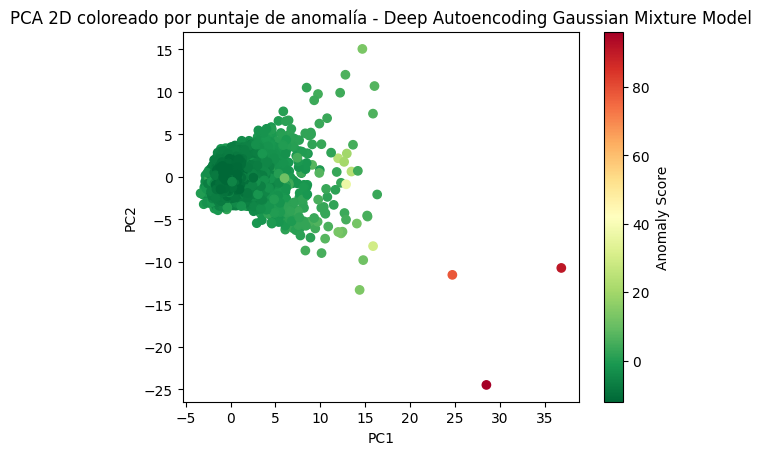

In [20]:
plot_pca_score(
    df=df_scored_dagmm,
    features=features,
    score_col='dagmm_energy',
    title="PCA 2D coloreado por puntaje de anomalía - Deep Autoencoding Gaussian Mixture Model"
)

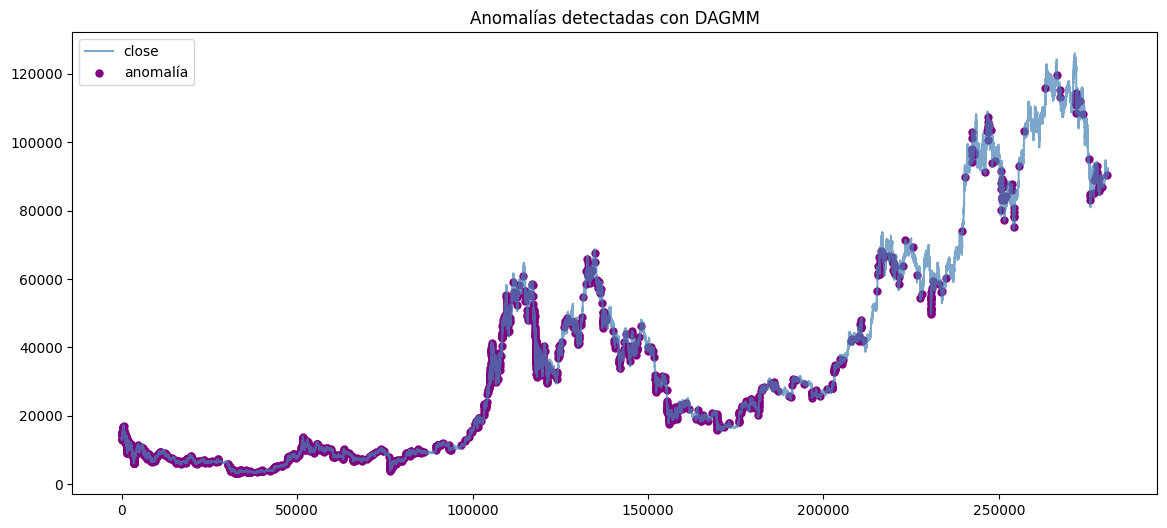

In [21]:
plot_close_anomalies(
    df=df_scored_dagmm,
    close_col="close",
    anomaly_col="anomaly_dagmm",
    title="Anomalías detectadas con DAGMM"
)